# Bit-Controlled Analog Output with Digilent Waveforms (pydwf)

✅ **Purpose**:  
This notebook configures the Digilent Analog Discovery (via the `pydwf` Python package) to output a DC voltage on **Wavegen Channel 1** (Analog Out) according to a provided bit string.

- For each bit in the string:
  - If the bit is `1`, output `1.0V`.
  - If the bit is `0`, output `0.0V`.
- Each output is held for exactly **1 second**.
- At the end, the output is reset to `0.0V`.

> Requires: Digilent Waveforms SDK installed and the `pydwf` package


In [2]:
import time
from pydwf import DwfLibrary, DwfAnalogOutNode, DwfAnalogOutFunction
from pydwf.utilities import openDwfDevice

# Import the function from your module
from dwf_funcs import create_figure, output_bitstream, ScanType, output_bitstream2, output_bitstream3, output_bitstream4, output_bitstream5, compute_bit_accuracy
from PIL import Image
import numpy as np

In [3]:
%matplotlib inline

In [4]:
def encode_bw_image(image: Image.Image) -> str:
    """
    Encode a black-and-white image into a bitstring.
    
    Parameters
    ----------
    image : PIL.Image.Image
        Input image. Must be in mode 'L' (grayscale) or '1' (1-bit).

    Returns
    -------
    bitstring : str
        A string of '1's and '0's, row-major flattened. '1' = black, '0' = white.
    """
    # Convert image to grayscale if not already
    if image.mode != 'L':
        image = image.convert('L')  # 8-bit pixels, black and white

    # Threshold to binary: 1 = black (pixel < 128), 0 = white (pixel ≥ 128)
    binary_array = np.array(image) < 128

    # Flatten row-major and convert to bitstring
    bitstring = ''.join(['1' if pixel else '0' for pixel in binary_array.flatten()])

    return bitstring


In [9]:
img = Image.open("snoopy_30x30.png")  # black & white square PNG
bitstream = encode_bw_image(img)
print(bitstream)  # preview first 64 bits

000000000000000000000000000000000000000000000000000000000000000000000000000111110000000000000000000000001000010000000000000000001111110000001000000000000000010000000000000100000000000000100000010100000110000000000001000110000000001011000000000001001110000000011101000000000001000000000000111101000000000001100000000000111101000000000000110000000010111101000000000000011100000100111101000000000000000011101000111010000000000000000000110001011100000000000000000000010010000000000000000000000000111110000000000000000000000000010011000000000000000000000000100001000000000000000000000001000001100000000000000000000001000000100000000000000000000011001000110000000000000000000011001001011000000000000000001110001001001000000000000000010000110001101000000000000000010101000000011100000000000000011111010100111011000000000000000001111111101110000000000000000000000000000000000000000000000000000000000000000000


In [6]:
# Define your bitstream and voltage parameters
bit_string = bitstream # replace with your pattern
voltage_high = 2.0         # voltage level for LED ON
voltage_low = 0.0          # voltage level for LED OFF
hold_time = 0.1          # seconds to hold each bit
record_length_time = 10.0

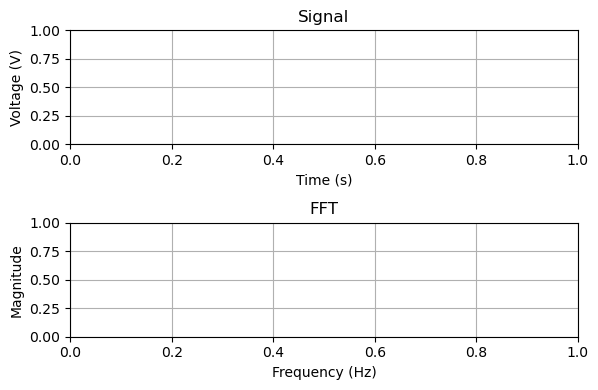

In [7]:
# %%
# Create a TEST figure (time + FFT)
fig, axs = create_figure(ScanType.TEST, figsize=(6, 4))


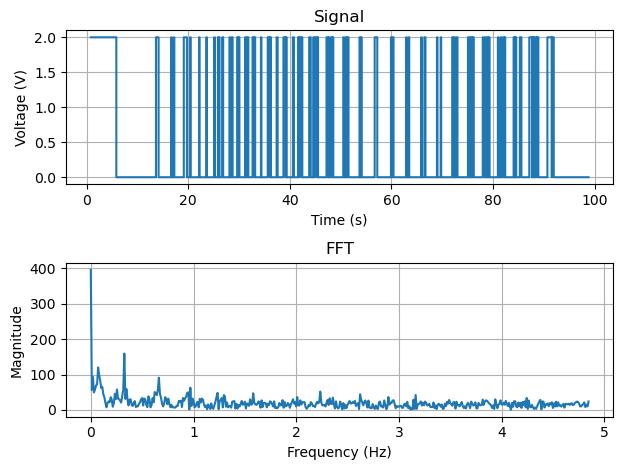

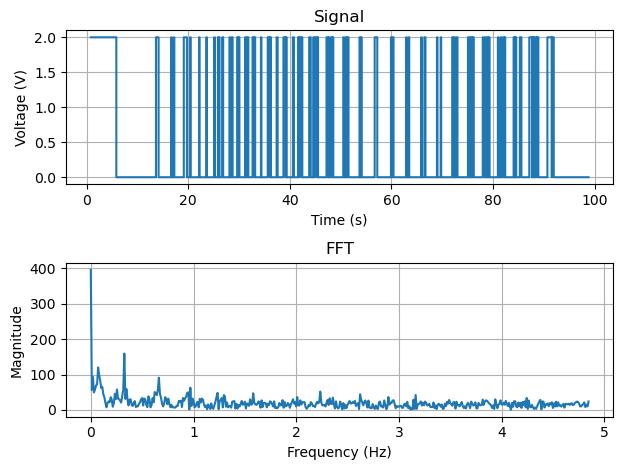

In [8]:
fig2, axs2 = output_bitstream2(
    bit_string=bit_string,
    voltage_high=voltage_high,
    voltage_low=voltage_low,
    hold_time=hold_time,
    #record_length_time=record_length_time
)

fig2

In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import csv
from pydwf import DwfLibrary, DwfAcquisitionMode
from pydwf.utilities import openDwfDevice


def record_scope_trace(duration_sec=10, sample_rate=10000):
    dwf = DwfLibrary()

    with openDwfDevice(dwf) as device:
        analog_in = device.analogIn

        # Configure oscilloscope
        analog_in.reset()
        analog_in.channelEnableSet(0, True)
        analog_in.channelRangeSet(0, 5.0)  # 0-5V range
        analog_in.acquisitionModeSet(DwfAcquisitionMode.Record)
        analog_in.frequencySet(sample_rate)
        analog_in.bufferSizeSet(8192)
        analog_in.recordLengthSet(duration_sec)

        analog_in.configure(reconfigure=True, start=True)
        print(f"Recording for {duration_sec} seconds...")

        total_samples = int(sample_rate * duration_sec)
        collected_data = []

        while True:
            status = analog_in.status(True)
            samples_left = analog_in.statusRecord()
            samples_available = analog_in.statusSamplesValid()
            if samples_available > 0:
                data_chunk = analog_in.statusData(0, samples_available)
                collected_data.extend(data_chunk)
            if status.name == "Done":
                break
            time.sleep(0.1)

        # Time vector
        t = np.linspace(0, duration_sec, len(collected_data))

        # Plot
        plt.figure()
        plt.plot(t, collected_data)
        plt.title("Oscilloscope Trace")
        plt.xlabel("Time (s)")
        plt.ylabel("Voltage (V)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # Save to CSV with timestamp-based filename
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"scope_trace_{timestamp}.csv"
        with open(filename, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(["Time (s)", "Voltage (V)"])
            writer.writerows(zip(t, collected_data))

        print(f"Trace saved to {filename}")


Recording for 60 seconds...


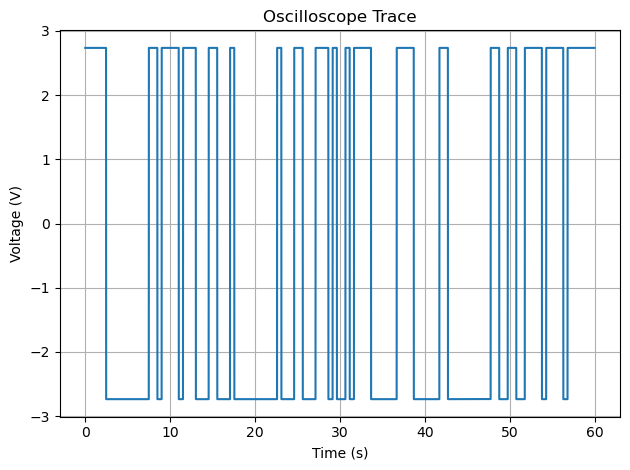

Trace saved to scope_trace_20250502_144843.csv


(array([0.00000000e+00, 1.00000167e-04, 2.00000333e-04, ...,
        5.99998000e+01, 5.99999000e+01, 6.00000000e+01], shape=(600000,)),
 array([2.73669573, 2.73669573, 2.73669573, ..., 2.73669573, 2.73669573,
        2.73669573], shape=(600000,)))

In [20]:
record_scope_trace(duration_sec=60, sample_rate=10000)


In [7]:
import time
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import csv
from pydwf import DwfLibrary, DwfAcquisitionMode
from pydwf.utilities import openDwfDevice


def record_scope_trace(duration_sec=10, sample_rate=10000):
    """
    Records a scope trace using a Digilent device for a given duration.

    Returns:
    - time_array: numpy array of time points (seconds)
    - voltage_array: numpy array of voltage values (volts)
    """
    dwf = DwfLibrary()

    with openDwfDevice(dwf) as device:
        analog_in = device.analogIn

        # Configure oscilloscope
        analog_in.reset()
        analog_in.channelEnableSet(0, True)
        analog_in.channelRangeSet(0, 5.0)
        analog_in.acquisitionModeSet(DwfAcquisitionMode.Record)
        analog_in.frequencySet(sample_rate)
        analog_in.bufferSizeSet(8192)
        analog_in.recordLengthSet(duration_sec)

        analog_in.configure(reconfigure=True, start=True)
        print(f"Recording for {duration_sec} seconds...")

        total_samples = int(sample_rate * duration_sec)
        collected_data = []

        while True:
            status = analog_in.status(True)
            samples_left = analog_in.statusRecord()
            samples_available = analog_in.statusSamplesValid()
            if samples_available > 0:
                data_chunk = analog_in.statusData(0, samples_available)
                collected_data.extend(data_chunk)
            if status.name == "Done":
                break
            time.sleep(0.1)

        voltage_array = np.array(collected_data)
        time_array = np.linspace(0, duration_sec, len(voltage_array))

        # Plot
        plt.figure()
        plt.plot(time_array, voltage_array)
        plt.title("Oscilloscope Trace")
        plt.xlabel("Time (s)")
        plt.ylabel("Voltage (V)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # Save to CSV
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"scope_trace_{timestamp}.csv"
        with open(filename, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(["Time (s)", "Voltage (V)"])
            writer.writerows(zip(time_array, voltage_array))

        print(f"Trace saved to {filename}")

    return time_array, voltage_array


Recording for 20 seconds...


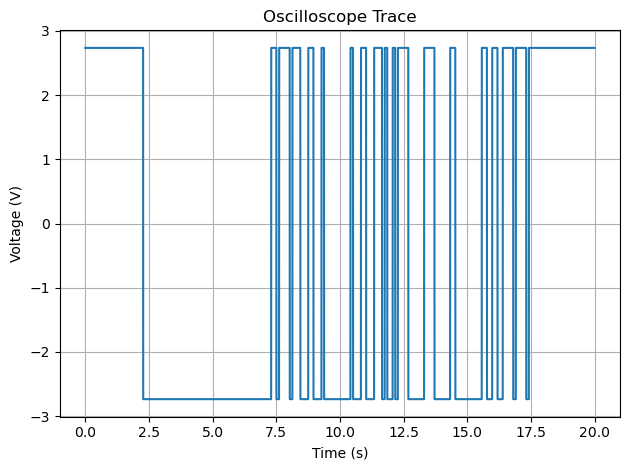

Trace saved to scope_trace_20250502_151833.csv


In [72]:
t, v = record_scope_trace(duration_sec=20, sample_rate=10000)

[0.000000e+00 1.000005e-04 2.000010e-04 ... 1.999980e+01 1.999990e+01
 2.000000e+01]


In [70]:
import numpy as np

def decode_bitstream_from_trace(time_array, voltage_array, tbit):
    """
    Decode a bitstream from the scope trace.

    Parameters:
    - time_array: array of time values (seconds)
    - voltage_array: array of voltage values (volts)
    - tbit: duration of one bit (seconds)

    Returns:
    - bitstring: a string of '0's and '1's
    """

    tbit = tbit + 0.003


    # Step 1: Detect where voltage is below 0V for at least 3 seconds
    below_zero = voltage_array < 0
    time_diff = np.diff(time_array, prepend=time_array[0])
    cumulative_below = np.cumsum(time_diff * below_zero)

    trigger_start = None
    trigger_end = None
    for i in range(len(cumulative_below)):
        if cumulative_below[i] >= 3.0:
            trigger_start = i
            break

    if trigger_start is None:
        print("No negative voltage period >3s found.")
        return ""

    for j in range(trigger_start, len(voltage_array)):
        if voltage_array[j] > 0:
            trigger_end = j
            break

    if trigger_end is None:
        print("Voltage never returned positive after negative period.")
        return ""

    # Step 2: Calculate dynamic threshold
    v_high = np.percentile(voltage_array, 90)
    v_low = np.percentile(voltage_array, 10)
    threshold = (v_high + v_low) / 2

    # Step 3: Wait tbit - tbit/2 seconds after voltage goes negative (center first bit)
    trigger_time = time_array[trigger_end] + tbit - (tbit/2)
    start_index = np.searchsorted(time_array, trigger_time)

    # Step 4: Decode bitstream
    bitstring = ""
    current_time = time_array[start_index]
    while current_time + tbit <= time_array[-1]:
        interval_start = np.searchsorted(time_array, current_time)
        interval_end = np.searchsorted(time_array, current_time + tbit)
        avg_voltage = np.mean(voltage_array[interval_start:interval_end])
        bitstring += '0' if avg_voltage > threshold else '1'
        current_time += tbit

    return bitstring



In [73]:
creeperbit = decode_bitstream_from_trace(t, v, 0.1)

print((creeperbit))
print(len(creeperbit))

01100001000111001110111111111101110011100010110100001111110000111111001111111111001100110000100001000000000000000000000000
122


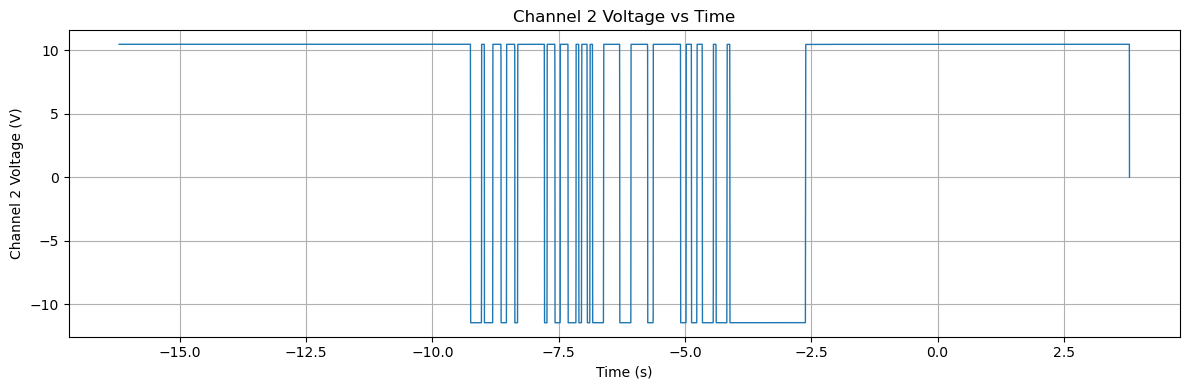

In [45]:
import matplotlib.pyplot as plt

# Define file path
file_path = '/Users/nadiathesun/Desktop/Physics111AFinalProject/final proj encoded creeper image signal test.csv'

# Read file and isolate data lines
with open(file_path, 'r', encoding='utf-8') as file:
    lines = file.readlines()

# Find index of the line with the header
header_index = next(i for i, line in enumerate(lines) if line.startswith("Time (s)"))

# Extract the data lines after the header
data_lines = lines[header_index + 1:]

# Parse times and voltages
times = []
voltages = []
for line in data_lines:
    parts = line.strip().split(',')
    if len(parts) == 3:
        try:
            times.append(float(parts[0]))
            voltages.append(float(parts[2]))
        except ValueError:
            continue  # skip lines with invalid data

# Plot the data
plt.figure(figsize=(12, 4))
plt.plot(times, voltages, linewidth=1)
plt.title('Channel 2 Voltage vs Time')
plt.xlabel('Time (s)')
plt.ylabel('Channel 2 Voltage (V)')
plt.grid(True)
plt.tight_layout()
plt.show()




In [39]:
ts = np.array(times)
vs = np.array(voltages)


bitstream = decode_bitstream_from_trace(ts, vs, tbit=0.051)
print(bitstream)

11101111000110001000000000001000110001110100101111100000011110000000110000000000111001100111101111001111111111111111111111111111100000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000


In [68]:
creeperbit = bitstream[:100]

print((creeperbit))

1110111100011000100000000000100011000111010010111110000001111000000011000000000011100110011110111100


In [13]:
import numpy as np
import matplotlib.pyplot as plt

def bitstring_to_image(bitstring):
    """
    Converts a 100-bit string to a 10x10 image and displays it.

    Parameters:
    - bitstring: A string of 100 bits ('0' and '1')
    """
    if len(bitstring) != 100:
        raise ValueError("Bitstring must be exactly 100 bits long.")

    # Convert to array of integers (0 and 1)
    bit_array = np.array([int(b) for b in bitstring])

    # Reshape to 10x10
    image_array = bit_array.reshape((10, 10))

    # Display image
    plt.imshow(image_array, cmap='gray', interpolation='nearest')
    plt.title("10x10 Bit Image")
    plt.axis('off')
    plt.show()


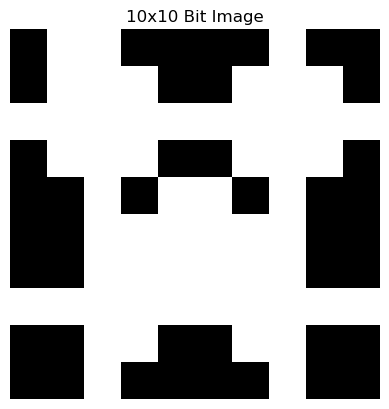

Accuracy: 99.00000% (99/100 bits compared)


(0.99, 99, 100)

In [74]:
def compute_bit_accuracy(decoded, reference):
    """
    Compare decoded bitstring to reference and compute accuracy.

    Parameters:
    - decoded: the decoded bitstring (string of '0's and '1's)
    - reference: the correct reference bitstring

    Returns:
    - accuracy: fraction of matching bits (0.0 to 1.0)
    - matching: number of matching bits
    - total: number of bits compared
    """
    # Compare only up to the length of the shorter string
    min_length = min(len(decoded), len(reference))
    matches = sum(d == r for d, r in zip(decoded[:min_length], reference[:min_length]))
    accuracy = matches / min_length if min_length > 0 else 0.0

    print(f"Accuracy: {accuracy:.5%} ({matches}/{min_length} bits compared)")
    return accuracy, matches, min_length



bitstring_to_image(creeperbit[:100])
compute_bit_accuracy(creeperbit[:100], '0010000100011100111011111111110111001110001011010000111111000011111100111111111100110011000010000100')


In [14]:
bitstring_to_image(creeperbit)

ValueError: Bitstring must be exactly 100 bits long.